In [7]:
import pandas as pd

df = pd.read_csv("data.csv", encoding='latin1')

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [8]:
print(df.isnull().sum())

df = df.dropna()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [12]:
import pandas as pd

data = pd.read_csv("data.csv",encoding='latin1' )

data_mean = data.fillna(data.mean(numeric_only=True))
print(data_mean.head())


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [13]:
import pandas as pd

data = pd.read_csv("data.csv",encoding='latin1')

data_median = data.fillna(data.median(numeric_only=True))
print(data_median.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [14]:
import pandas as pd

data = pd.read_csv("data.csv",encoding='latin1')

data_mode = data.fillna(data.mode().iloc[0])
print(data_mode.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [16]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
print(top_products.head(10))

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: Quantity, dtype: int64


In [22]:
import pandas as pd
import datetime as dt

# Load dataset
data = pd.read_csv("data.csv", encoding='latin1')



# Create Total Price
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]

# Convert date
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

# Create snapshot date
snapshot_date = data["InvoiceDate"].max() + dt.timedelta(days=1)

# Create RFM features
rfm = data.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "count",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

# Function to assign customer segment
def segment(recency, frequency, monetary):
    if monetary > 10000 and frequency > 50:
        return "High Value "
    elif frequency > 20:
        return "Frequent Buyer "
    elif recency < 30:
        return "Recent Customer "
    else:
        return "Low Engagement "

# Apply segmentation
rfm["Customer_Segment"] = rfm.apply(
    lambda row: segment(row["Recency"], row["Frequency"], row["Monetary"]),
    axis=1
)

# Display result
print(rfm.head())

            Recency  Frequency  Monetary Customer_Segment
CustomerID                                               
12346.0         326          2      0.00  Low Engagement 
12347.0           2        182   4310.00  Frequent Buyer 
12348.0          75         31   1797.24  Frequent Buyer 
12349.0          19         73   1757.55  Frequent Buyer 
12350.0         310         17    334.40  Low Engagement 


In [27]:
from sklearn.model_selection import train_test_split

X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Customer_Segment"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\Thangam\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8342857142857143


In [30]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[576   4  19   0]
 [  8  12   0   0]
 [ 70   0 142   0]
 [ 42   1   1   0]]


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

 Frequent Buyer        0.83      0.96      0.89       599
     High Value        0.71      0.60      0.65        20
 Low Engagement        0.88      0.67      0.76       212
Recent Customer        0.00      0.00      0.00        44

        accuracy                           0.83       875
       macro avg       0.60      0.56      0.57       875
    weighted avg       0.80      0.83      0.81       875



C:\Users\Thangam\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Thangam\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Thangam\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [33]:
# Sample = [Recency, Frequency, Monetary]
sample = [[30, 10, 2000]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Customer Likely to Churn ")
else:
    print("Customer Will Stay ")

Customer Will Stay 


C:\Users\Thangam\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


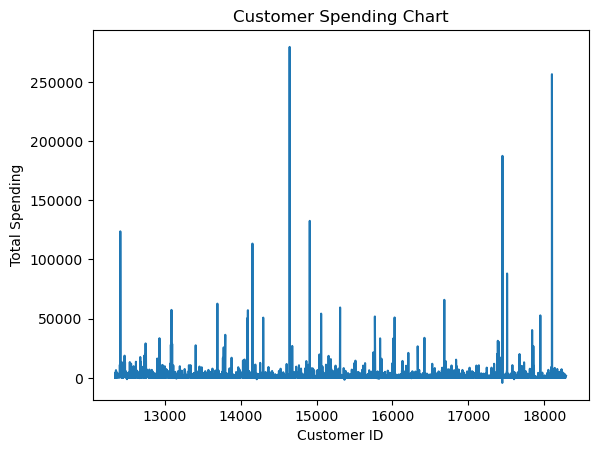

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data.csv", encoding='latin1')

# Remove null values
data = data.dropna()

# Create Total Price
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]

# Group by Customer
customer_spending = data.groupby("CustomerID")["TotalPrice"].sum()

# Plot
plt.plot(customer_spending.index, customer_spending.values)
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.title("Customer Spending Chart")
plt.show()

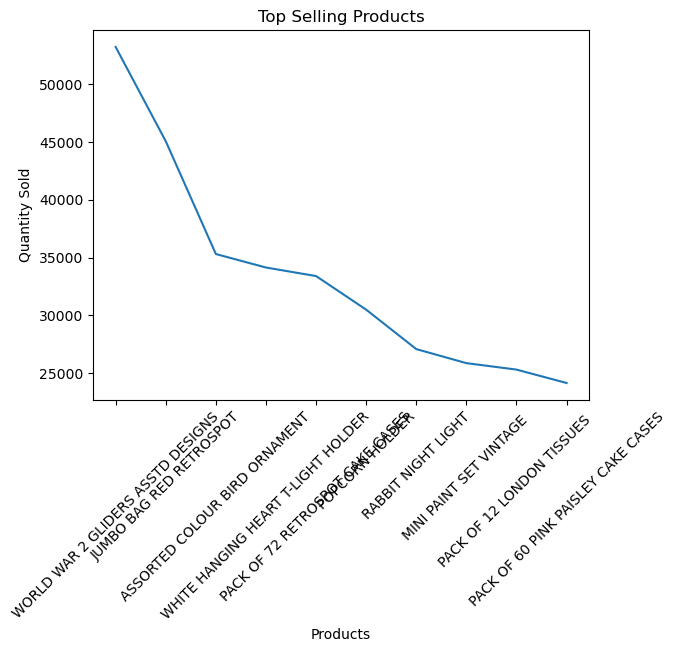

In [37]:
top_products = data.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.plot(top_products.index, top_products.values)
plt.xlabel("Products")
plt.ylabel("Quantity Sold")
plt.title("Top Selling Products")
plt.xticks(rotation=45)
plt.show()